In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append("./src")
from nahiku import Nahiku

/mnt/lustre/koa/koastore/sadow_group/personal/linneamw/research/dipper_detection/nahiku/src/exhaustive_search.py:347: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(self.x, pred_mean, lw=1, alpha=0.7, label="Predicted $\pm$ 1 $\sigma$")


# Create a Nahiku object from a (x, y) time series, inject an exocomet-shaped anomaly, and recover it using the Greedy Search method

### 1.) Create a simple sinusoid with noise

/mnt/lustre/koa/koastore/sadow_group/personal/linneamw/research/dipper_detection/nahiku/src/nahiku.py:500: UserWarning: Data is not standardized, and will be standardized for estimating the dominant period.
  warnings.warn("Data is not standardized, and will be standardized for estimating the dominant period.")


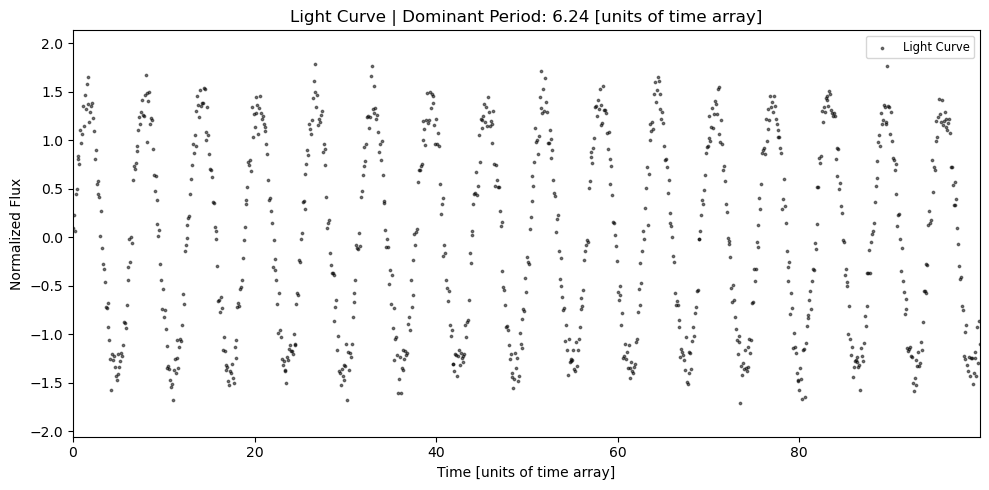

In [2]:
x = np.arange(0, 100, 0.1)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

nahiku = Nahiku(x, y)
nahiku.plot()

### 2.) Inject an anomaly at index 350 with an exocomet shape, absolute width of 0.5 (in units of the time array), and absolute depth of 5 (in units of the flux array)

Injected exocomet-shaped anomaly with amplitude -1.85, width 0.50, and FWHM 1.23 at index 350 (time 35.00 [units of time array])
Current nahiku.anomalies dictionary: {'true': [], 'injected': [350], 'identified': []}


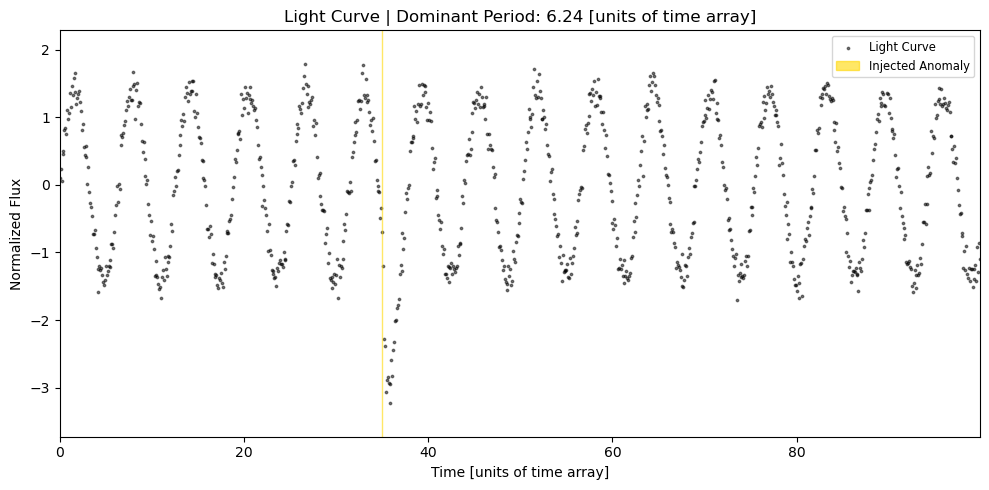

In [3]:
anomaly_idxs, _, _, _ = nahiku.inject_anomaly(1, absolute_width=0.5, absolute_depth=5, shapes=["exocomet"], idxs=[350])
print(f"Current nahiku.anomalies dictionary: {nahiku.anomalies}")
nahiku.plot()

### 3.) Search for an injected anomaly using the greedy_search method, with plot=True to visualize the search process

No y_err provided. Using y_err = 0 for all points. Note that y_err is only used for calculating residuals, not in GP training.


Using 100 as minimum iterations for early stopping.
Early stopping at iteration 108 due to increasing train loss.


/home/linneamw/anaconda3/envs/dipper_detect/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:284: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


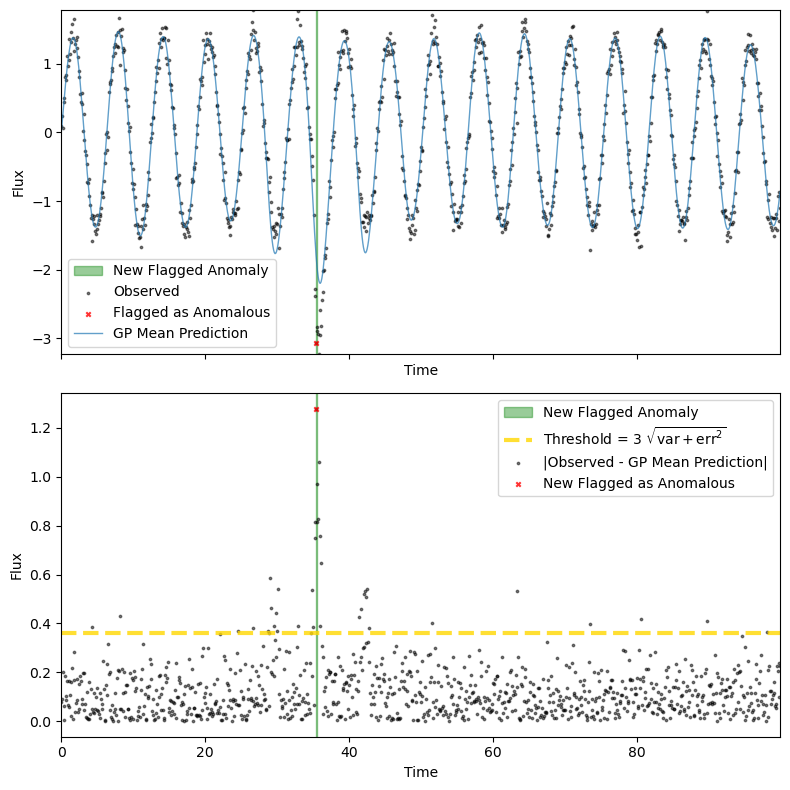

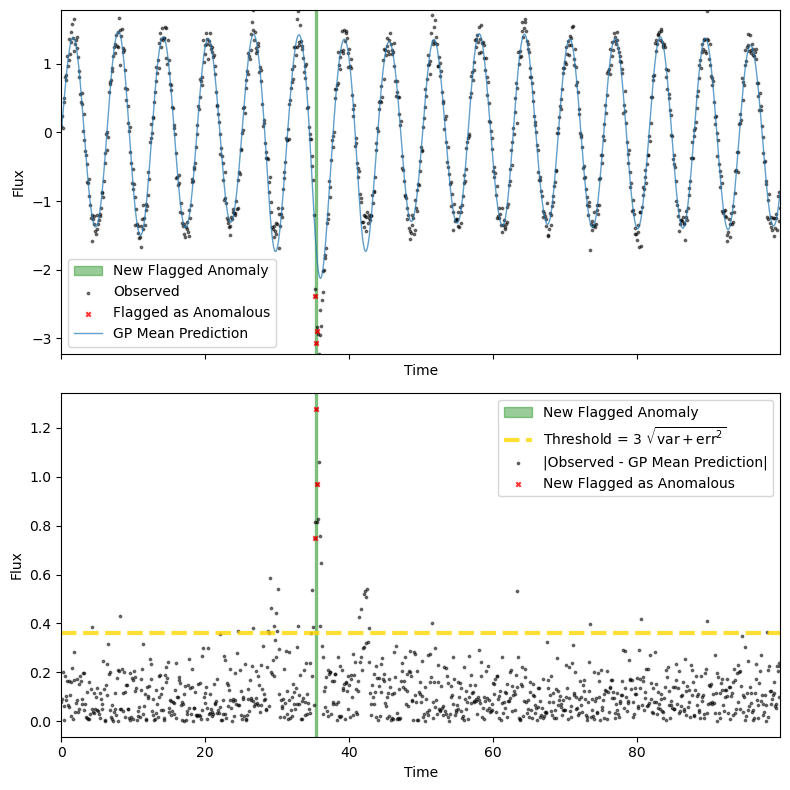

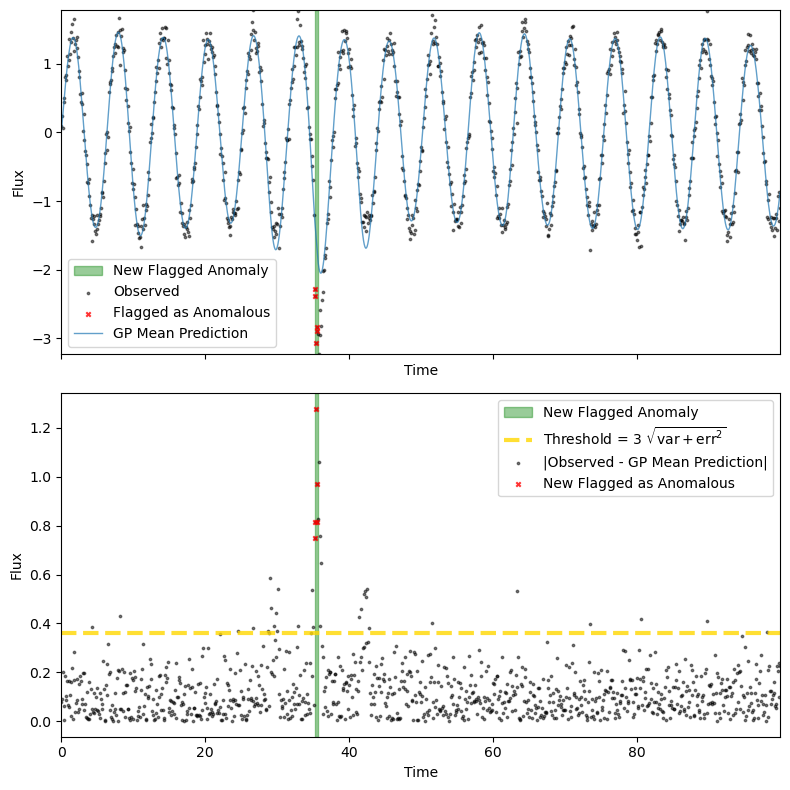

Anomalous edges = 352:357
The greedy search took 7.62 seconds to run, and found 1 anomalous intervals.
Greedy search found 1 anomalous intervals.
Current nahiku.anomalies dictionary: {'true': [], 'injected': [350], 'identified': [352, 353, 354, 355, 356]}


In [4]:
greedy_search = nahiku.greedy_search(plot=True)
print(f"Greedy search found {greedy_search.num_detected_anomalies} anomalous intervals.")
print(f"Current nahiku.anomalies dictionary: {nahiku.anomalies}")

### 4.) Plot and check whether the detected anomaly matches the injected anomaly

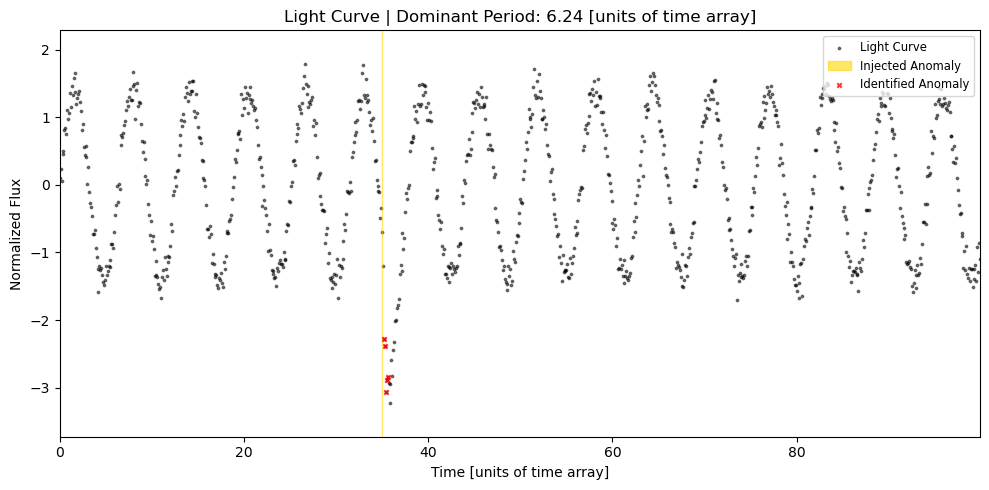

Events Detected: 1 / 1
Event-wise TPR: 1.00
False Positive Events: 0
Event-wise Precision: 1.00


{'tpr': 1.0, 'precision': 1.0, 'detected_count': 1, 'false_positives': 0}

In [5]:
nahiku.plot()
nahiku.check_identified_anomalies(buffer=10)

# Create a Nahiku object from a synthetic time series (sampled from a parameterized Gaussian Process), inject a gaussian-shaped anomaly, and recover it using the Exhaustive Search method

### 1.) Create a simple synthetic light curve from parameterized red and white noise, then a synthetic light curve by sampling from a Gaussian Process with a Quasi-Periodic kernel

/mnt/lustre/koa/koastore/sadow_group/personal/linneamw/research/dipper_detection/nahiku/src/nahiku.py:500: UserWarning: Data is not standardized, and will be standardized for estimating the dominant period.
  warnings.warn("Data is not standardized, and will be standardized for estimating the dominant period.")


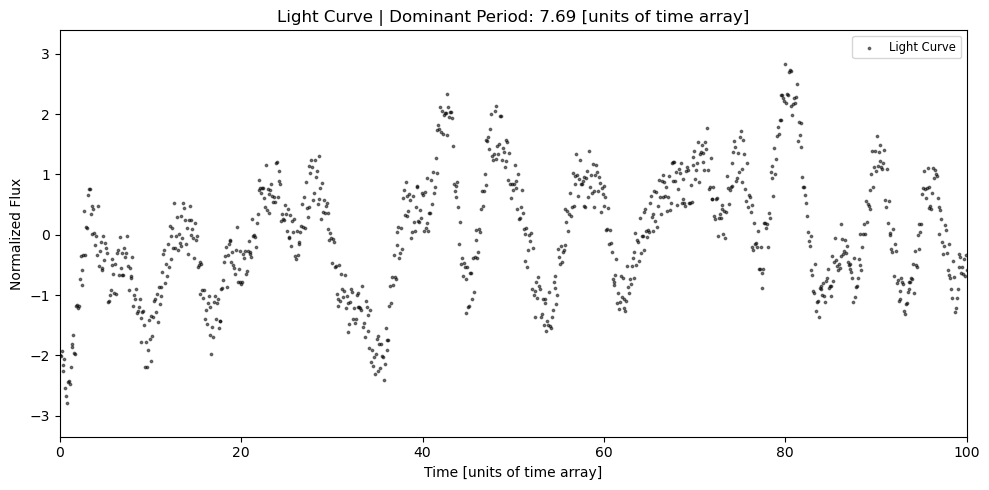

In [6]:
# Synthetic light curve from parameterized noise values
nahiku = Nahiku.from_synthetic_parameterized_noise(num_steps=1000)
nahiku.plot()

Light curve before prewhitening:


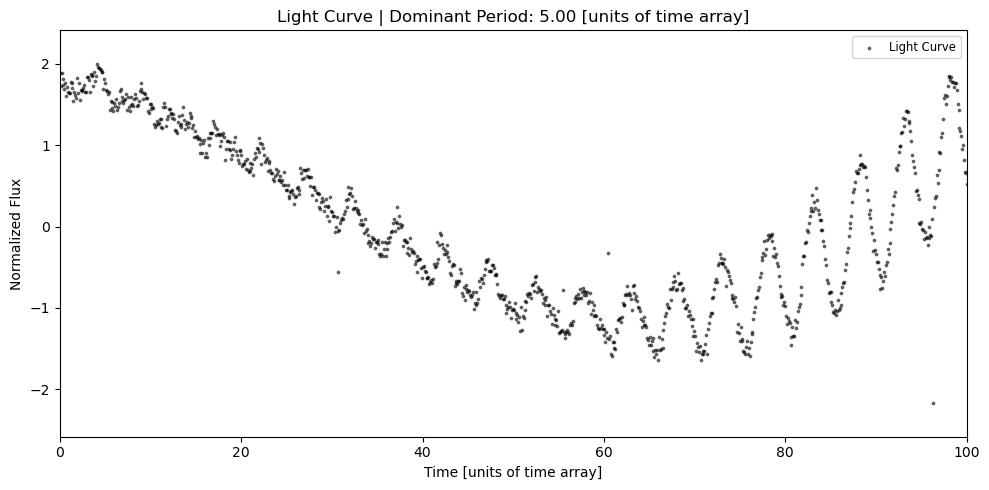

  0%|          | 0/100 [00:00<?, ?it/s]

Light curve after prewhitening:


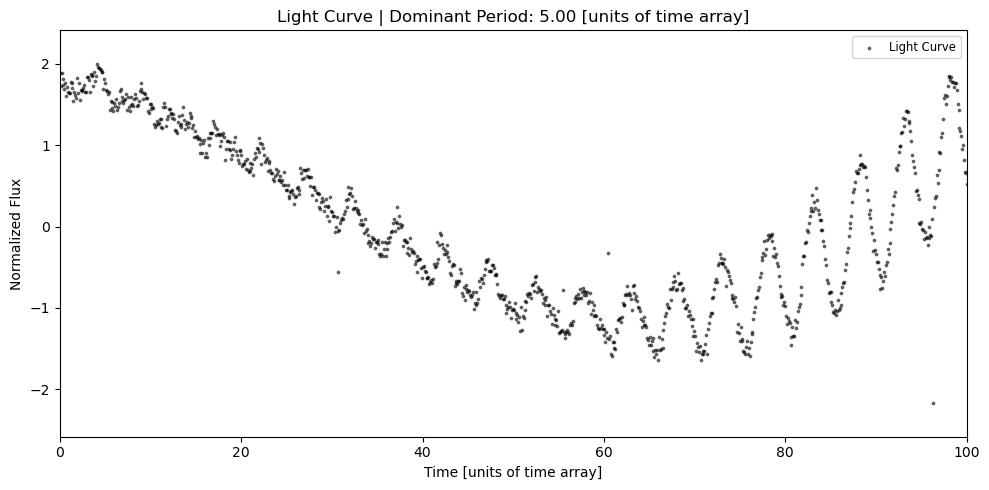

In [7]:
# Synthetic light curve from a GP
nahiku = Nahiku.from_synthetic_parameterized_gp(num_days=100, num_steps=1000, period=5, noise_std=0.1, add_high_residuals=True, num_high_residuals=5)

# Prewhiten
nahiku.prewhiten(plot=True)

### 2.) Inject an anomaly at index 200 with a gaussian shape, absolute width of 1 (in units of the time array), and absolute depth of 3 (in units of the flux array)

Injected gaussian-shaped anomaly with amplitude -4.00, width 2.00, and FWHM 4.71 at index 210 (time 21.02 [units of time array])
Current nahiku.anomalies dictionary: {'true': [], 'injected': [210], 'identified': []}


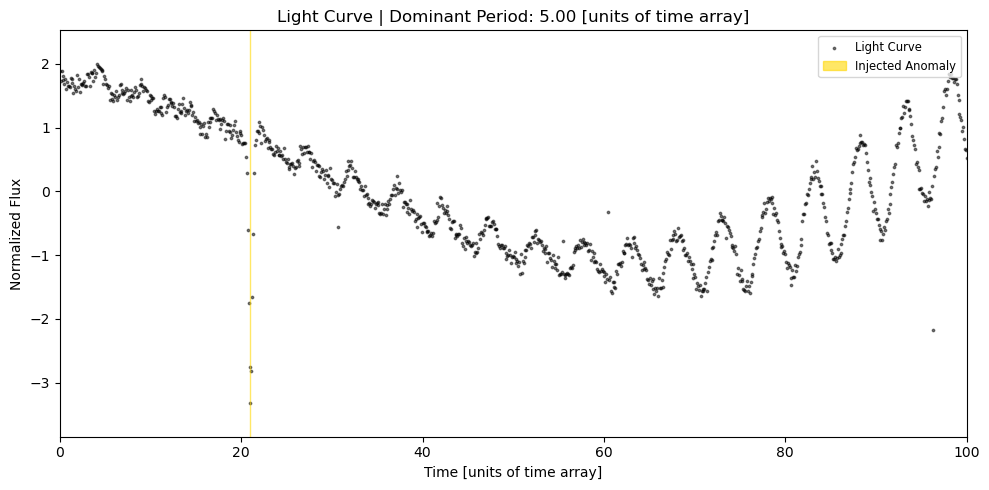

In [8]:
anomaly_idxs, _, _, _ = nahiku.inject_anomaly(1, absolute_width=2, absolute_depth=4, shapes=["gaussian"], idxs=[210])
print(f"Current nahiku.anomalies dictionary: {nahiku.anomalies}")
nahiku.plot()

### 3.) Search for an injected anomaly using the exhaustive_search method, with plot=True to visualize the search process

In [9]:
greedy_search = nahiku.exhaustive_search(plot=False, silent=False, min_anomaly_len=10, max_anomaly_len=100, window_slide_step=50, window_size_step=30, dynamic_programming=True)
print(f"Exhaustive search found {greedy_search.num_detected_anomalies} anomalous intervals.")
print(f"Current nahiku.anomalies dictionary: {nahiku.anomalies}")

Using 100 as minimum iterations for early stopping.
Early stopping at iteration 112 due to increasing train loss.
Anomaly interval: 0-10, metric pval over the interval: 0.9999542007236275, pos or neg: 1
Anomaly interval: 0-40, metric pval over the interval: 0.9999999999999591, pos or neg: 1
Anomaly interval: 0-70, metric pval over the interval: 1.0, pos or neg: 1
Anomaly interval: 50-60, metric pval over the interval: 0.9999772216148199, pos or neg: -1
Anomaly interval: 50-90, metric pval over the interval: 1.0, pos or neg: -1
Anomaly interval: 50-120, metric pval over the interval: 1.0, pos or neg: -1
Anomaly interval: 100-110, metric pval over the interval: 0.9999983952203285, pos or neg: -1
Anomaly interval: 100-140, metric pval over the interval: 1.0, pos or neg: -1
Anomaly interval: 100-170, metric pval over the interval: 0.9957137487351043, pos or neg: 1
Anomaly interval: 150-160, metric pval over the interval: 0.45140935224826495, pos or neg: 1
Anomaly interval: 150-190, metric 

### 4.) Plot and check whether the detected anomaly matches the injected anomaly

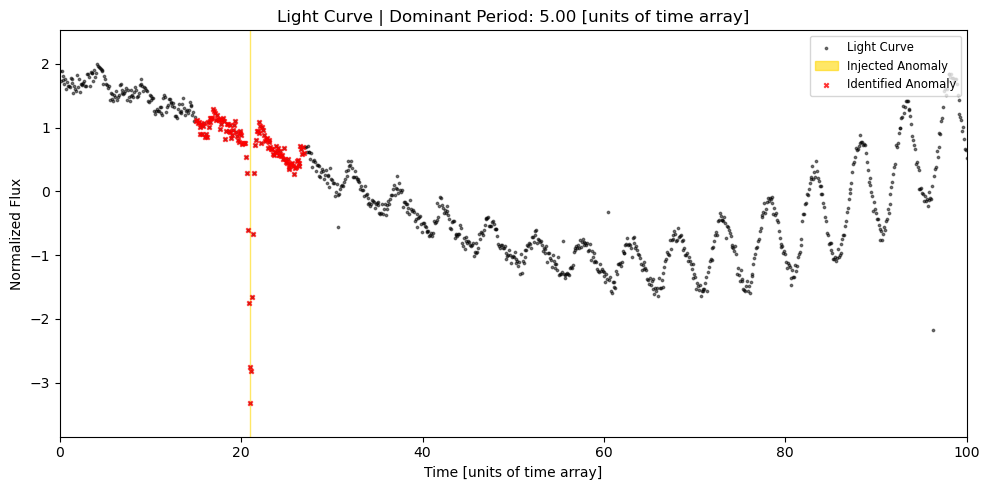

Events Detected: 1 / 1
Event-wise TPR: 1.00
False Positive Events: 0
Event-wise Precision: 1.00


{'tpr': 1.0, 'precision': 1.0, 'detected_count': 1, 'false_positives': 0}

In [10]:
nahiku.plot()
nahiku.check_identified_anomalies(buffer=10)